# 使用自動微分估算簡單線性迴歸的參數(w、b)
## $ y = wx + b$

In [1]:
# 載入套件
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import LinearRegression

## 定義訓練函數

In [2]:
def train(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 100,
    lr: float = 0.0_001,
):
    loss_list: list[float] = []
    w_list: list[float] = []
    b_list: list[float] = []

    # w、b 初始值均設為常態分配之隨機亂數
    w = torch.randn(1, requires_grad=True, dtype=torch.float)
    b = torch.randn(1, requires_grad=True, dtype=torch.float)
    for epoch in range(epochs):  # 執行訓練週期
        y_pred = w * X + b  # 預測值

        # 計算損失函數值
        # MSE = torch.square(y - y_pred).mean()
        # MSE = (y - y_pred).square().mean()
        MSE = ((y - y_pred) ** 2).mean()
        MSE.backward()

        # 設定不參與梯度下降，w、b才能運算
        with torch.no_grad():
            # 新權重 = 原權重 — 學習率(learning_rate) * 梯度(gradient)
            assert w.grad is not None
            assert b.grad is not None
            w -= lr * w.grad
            b -= lr * b.grad

        # 記錄訓練結果
        if (epoch + 1) % 1000 == 0 or epochs < 1000:
            # detach：與運算圖分離，numpy()：轉成陣列
            # w.detach().numpy()
            w_list.append(w.item())  # w.item()：轉成常數
            b_list.append(b.item())
            loss_list.append(MSE.item())

        # 梯度重置
        assert w.grad is not None
        assert b.grad is not None
        w.grad.zero_()
        b.grad.zero_()

    return w_list, b_list, loss_list

## 產生隨機資料

In [3]:
# 產生線性隨機資料100筆，介於 0-50
n = 100
X = np.linspace(0, 50, n)
y = np.linspace(0, 50, n)

# 資料加一點雜訊(noise)
X += np.random.uniform(-10, 10, n)
y += np.random.uniform(-10, 10, n)

## 執行訓練

In [4]:
# 執行訓練
w_list, b_list, loss_list = train(torch.tensor(X), torch.tensor(y))

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.9269730448722839, b=0.0936441421508789


In [5]:
# 執行訓練
w_list, b_list, loss_list = train(torch.tensor(X), torch.tensor(y), epochs=100_000)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.8704826831817627, b=2.0986227989196777


## 以NumPy驗證

In [6]:
# 執行訓練
coef = np.polyfit(X, y, deg=1)

# 取得 w、b 的最佳解
print(f'w={coef[0]}, b={coef[1]}')

w=0.870255164159062, b=2.1066959638726757


In [7]:
X2 = X.reshape(X.shape[0], 1)

lr = LinearRegression()
lr.fit(X2, y)

lr.coef_[0], lr.intercept_

(np.float64(0.8702551641590617), np.float64(2.1066959638726743))

## 顯示迴歸線

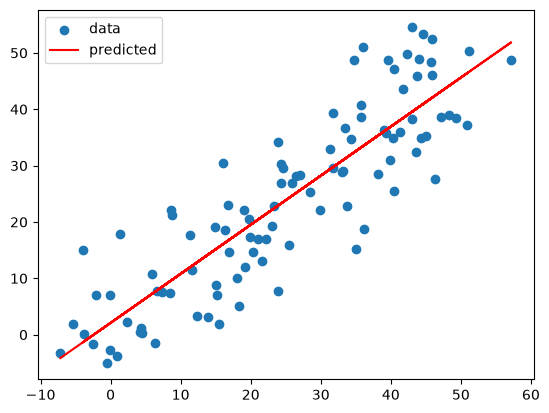

In [8]:
plt.scatter(X, y, label='data')
plt.plot(X, w_list[-1] * X + b_list[-1], 'r-', label='predicted')
plt.legend()

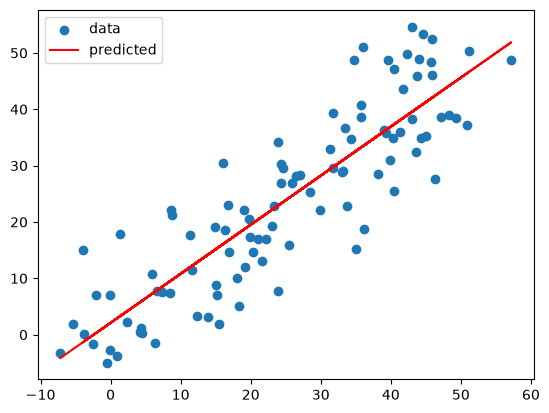

In [9]:
# NumPy 求得的迴歸線
plt.scatter(X, y, label='data')
plt.plot(X, coef[0] * X + coef[1], 'r-', label='predicted')
plt.legend()

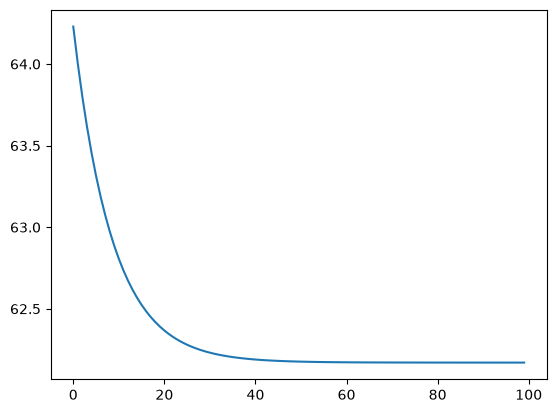

In [10]:
# 損失函數繪圖
plt.plot(loss_list)

In [11]:
loss_list

[64.22939516518731,
 64.00124603085675,
 63.79837695396296,
 63.6179868410476,
 63.45758488691683,
 63.314956236390366,
 63.18813153364694,
 63.075359704717954,
 62.97508362761857,
 62.88591881194256,
 62.806633755649266,
 62.736133780921236,
 62.67344568060482,
 62.61770333588209,
 62.568137750152964,
 62.524064137972324,
 62.48487438089825,
 62.450026885226634,
 62.419040894434126,
 62.39148820372122,
 62.366988490594196,
 62.345203492887556,
 62.32583223255846,
 62.30860744027571,
 62.29329105419136,
 62.279671995687465,
 62.267562068485915,
 62.25679405744191,
 62.247219011664896,
 62.23870471487184,
 62.23113436873084,
 62.224402555780124,
 62.21841667278302,
 62.21309402112732,
 62.208361296753445,
 62.204152814735465,
 62.200410501253174,
 62.19708299608237,
 62.19412455458548,
 62.191493613450895,
 62.18915399037176,
 62.187073871846714,
 62.18522430284851,
 62.183579497633076,
 62.18211690379778,
 62.180816685537955,
 62.17966016845985,
 62.17863191045977,
 62.17771785003402,


In [12]:
w_list

[0.9448361992835999,
 0.9405829906463623,
 0.936572253704071,
 0.932790219783783,
 0.9292240738868713,
 0.9258610010147095,
 0.9226898550987244,
 0.9196996092796326,
 0.9168799519538879,
 0.9142209887504578,
 0.9117135405540466,
 0.9093493223190308,
 0.9071199297904968,
 0.9050175547599792,
 0.9030351042747498,
 0.9011656641960144,
 0.8994027972221375,
 0.8977407217025757,
 0.8961731791496277,
 0.8946952223777771,
 0.8933013081550598,
 0.8919870853424072,
 0.8907477855682373,
 0.889579176902771,
 0.888477087020874,
 0.8874378204345703,
 0.8864580392837524,
 0.8855341076850891,
 0.8846626877784729,
 0.8838409781455994,
 0.8830661773681641,
 0.8823355436325073,
 0.8816467523574829,
 0.8809970021247864,
 0.8803845643997192,
 0.8798068165779114,
 0.8792619705200195,
 0.8787484169006348,
 0.8782640099525452,
 0.8778073787689209,
 0.8773767948150635,
 0.8769704699516296,
 0.8765876293182373,
 0.8762263059616089,
 0.8758858442306519,
 0.8755648732185364,
 0.8752618432044983,
 0.87497639656066

In [13]:
b_list

[-0.5403555631637573,
 -0.38939782977104187,
 -0.2470489889383316,
 -0.112818144261837,
 0.013757669366896152,
 0.13311505317687988,
 0.24566568434238434,
 0.3517976403236389,
 0.4518769681453705,
 0.5462486743927002,
 0.6352387070655823,
 0.7191538214683533,
 0.7982832193374634,
 0.8729004859924316,
 0.9432621598243713,
 1.0096113681793213,
 1.072176456451416,
 1.1311737298965454,
 1.1868059635162354,
 1.2392657995224,
 1.288733959197998,
 1.3353809118270874,
 1.3793679475784302,
 1.4208464622497559,
 1.4599599838256836,
 1.4968422651290894,
 1.5316210985183716,
 1.5644162893295288,
 1.5953418016433716,
 1.6245044469833374,
 1.652001976966858,
 1.6779325008392334,
 1.7023842334747314,
 1.7254416942596436,
 1.7471834421157837,
 1.767686128616333,
 1.7870203256607056,
 1.8052512407302856,
 1.8224403858184814,
 1.8386510610580444,
 1.8539385795593262,
 1.8683525323867798,
 1.8819440603256226,
 1.8947616815567017,
 1.9068487882614136,
 1.9182438850402832,
 1.928992509841919,
 1.9391270875